# Trader Performance vs Bitcoin Sentiment

Hyperliquid historical trades meet the Bitcoin Fear and Greed Index. The goal: figure out whether trader behaviour and results actually change across sentiment regimes, then rank traders inside each regime and call out the contrarian ones.

Sections:
1. Setup
2. Sentiment EDA
3. Trades EDA
4. Join and feature engineering
5. Regime-level performance
6. Statistical tests
7. Trader ranking and contrarian detection
8. Headline charts saved to disk


In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data_loader import load_trades, load_sentiment
from src.features import attach_sentiment, add_trade_features, daily_trader_agg, REGIME_ORDER
from src.metrics import all_metrics, metrics_by_group

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

FIG_DIR = Path('../outputs/figures') if Path.cwd().name == 'notebooks' else Path('outputs/figures')
TBL_DIR = Path('../outputs/tables') if Path.cwd().name == 'notebooks' else Path('outputs/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {
    'Extreme Fear': '#7a0d0d',
    'Fear': '#d0473a',
    'Neutral': '#9a9a9a',
    'Greed': '#3aa05a',
    'Extreme Greed': '#117a3a',
}
print('imports ok')


imports ok


## 2. Sentiment EDA

In [2]:
sent = load_sentiment()
print('shape:', sent.shape)
print('date range:', sent['date'].min().date(), 'to', sent['date'].max().date())
sent['regime'].value_counts().reindex(REGIME_ORDER)


shape: (2644, 3)
date range: 2018-02-01 to 2025-05-02


regime
Extreme Fear     508
Fear             781
Neutral          396
Greed            633
Extreme Greed    326
Name: count, dtype: int64

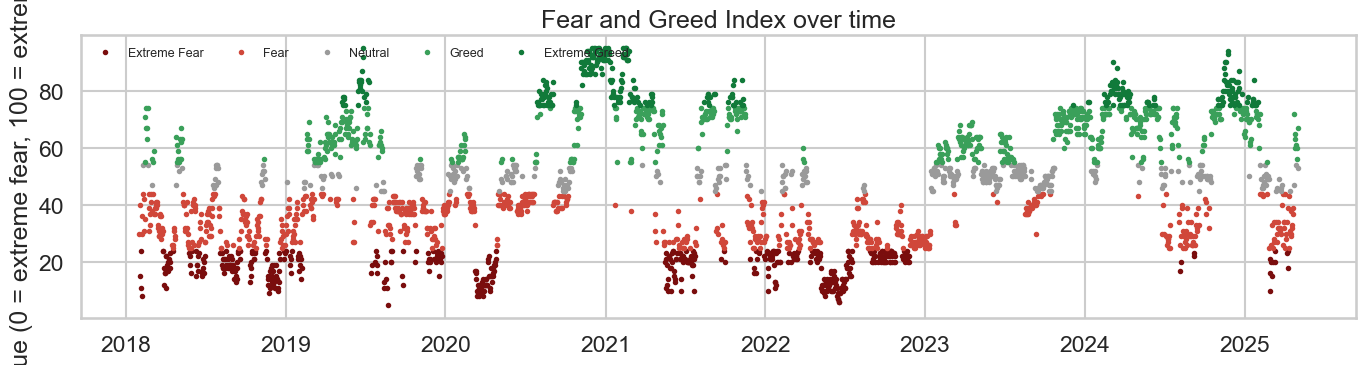

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
for r, color in PALETTE.items():
    mask = sent['regime'] == r
    ax.scatter(sent.loc[mask, 'date'], sent.loc[mask, 'fg_value'], s=6, color=color, label=r)
ax.set_title('Fear and Greed Index over time')
ax.set_ylabel('Index value (0 = extreme fear, 100 = extreme greed)')
ax.legend(loc='upper left', fontsize=9, ncol=5, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sentiment_timeline.png', dpi=140)
plt.show()


## 3. Trades EDA

In [4]:
trades = load_trades()
print('shape:', trades.shape)
print('date range:', trades['date'].min().date(), 'to', trades['date'].max().date())
print('unique accounts:', trades['account'].nunique())
print('unique coins:', trades['coin'].nunique())
trades.head(3)


shape: (211224, 18)
date range: 2023-05-01 to 2025-05-01
unique accounts: 32
unique coins: 246


,account,coin,exec_price,size_tokens,size_usd,side,Timestamp IST,start_position,direction,closed_pnl,Transaction Hash,Order ID,Crossed,fee,Trade ID,Timestamp,ts,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02


In [5]:
print('side mix:'); print(trades['side'].value_counts())
print()
print('top 10 coins by trade count:')
print(trades['coin'].value_counts().head(10))
print()
print('PnL describe:')
print(trades['closed_pnl'].describe())
print()
print('share of trades with non-zero closed PnL (i.e. closes):',
      round((trades['closed_pnl'] != 0).mean(), 3))


side mix:
side
SELL    108528
BUY     102696
Name: count, dtype: int64

top 10 coins by trade count:
coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64

PnL describe:
count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: closed_pnl, dtype: float64

share of trades with non-zero closed PnL (i.e. closes): 0.494


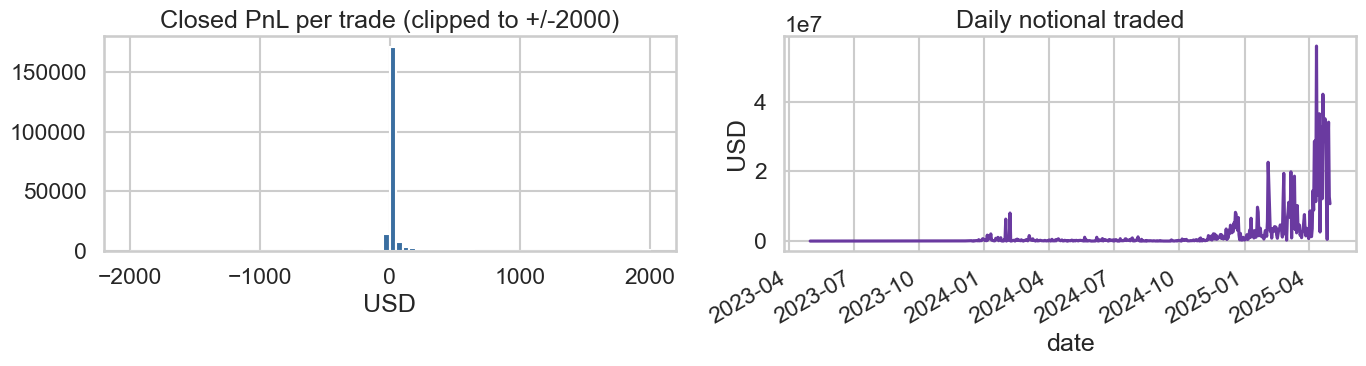

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
trades['closed_pnl'].clip(-2000, 2000).hist(bins=80, ax=axes[0], color='#3a6ea0')
axes[0].set_title('Closed PnL per trade (clipped to +/-2000)')
axes[0].set_xlabel('USD')

daily_volume = trades.groupby('date')['size_usd'].sum()
daily_volume.plot(ax=axes[1], color='#6a3aa0')
axes[1].set_title('Daily notional traded')
axes[1].set_ylabel('USD')
plt.tight_layout()
plt.savefig(FIG_DIR / 'trades_eda.png', dpi=140)
plt.show()


## 4. Join and feature engineering

Left-join trades onto the daily sentiment file. The sentiment series covers the full date range of the trades, so almost no trades go without a regime label.

In [7]:
df = attach_sentiment(trades, sent)
df = add_trade_features(df)
print('joined shape:', df.shape)
print('trades without a regime label:', df['regime'].isna().sum())
df[['account', 'coin', 'date', 'closed_pnl', 'size_usd', 'side', 'regime', 'fg_value']].head(5)


joined shape: (211224, 25)
trades without a regime label: 6


,account,coin,date,closed_pnl,size_usd,side,regime,fg_value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,7872.16,BUY,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,127.68,BUY,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,1150.63,BUY,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,1142.04,BUY,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,2024-12-02,0.0,69.75,BUY,Extreme Greed,80.0


## 5. Regime-level performance

Headline metrics computed on every trade in each regime.

In [8]:
regime_table = metrics_by_group(df.dropna(subset=['regime']), 'regime')
regime_table = regime_table.set_index('regime').reindex(REGIME_ORDER).reset_index()
regime_table.to_csv(TBL_DIR / 'metrics_by_regime.csv', index=False)
regime_table.round(4)


,regime,trades,pnl_total,pnl_mean,pnl_median,win_rate,profit_factor,sharpe,max_drawdown,trading_frequency,roi,risk_std
0,Extreme Fear,21400,7.391102e+05,34.5379,0.0,0.7622,2.1615,9.9605,-86890.7563,1528.5714,0.0065,1136.0561
1,Fear,61837,3.357155e+06,54.2904,0.0,0.8729,6.6556,7.2953,-135685.6661,679.5275,0.0069,935.3554
2,Neutral,37686,1.292921e+06,34.3077,0.0,0.8239,4.3213,9.7032,-10116.8756,562.4776,0.0072,517.1222
3,Greed,50303,2.150129e+06,42.7436,0.0,0.7689,3.0309,3.4094,-419020.2257,260.6373,0.0075,1116.0284
4,Extreme Greed,39992,2.715171e+06,67.8929,0.0,0.8917,11.0228,6.2481,-137369.6087,350.8070,0.0218,766.8283


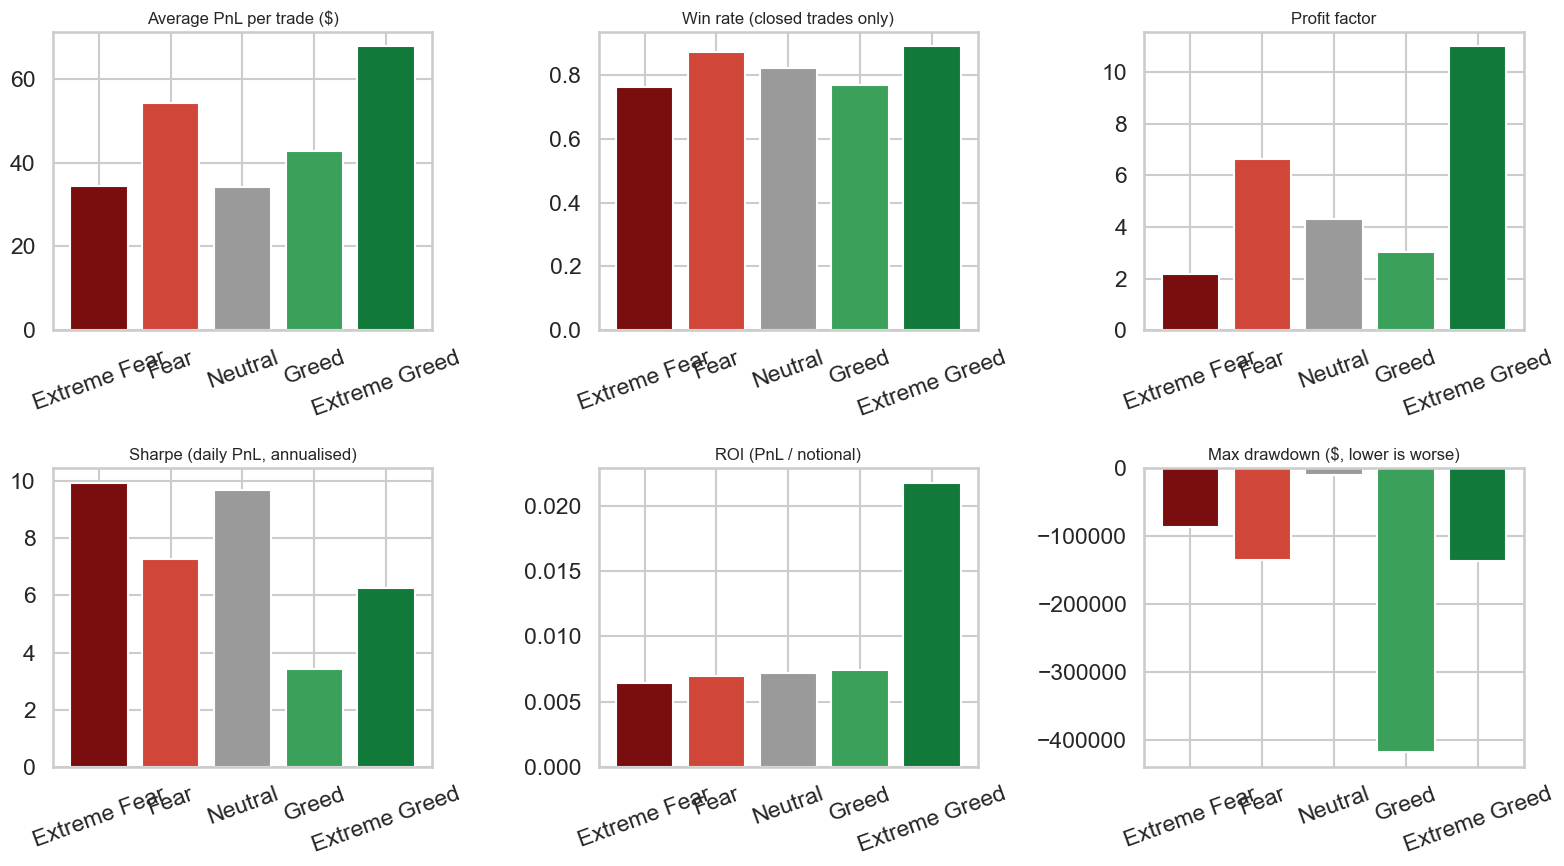

In [9]:
# Headline bar charts
metrics_to_plot = ['pnl_mean', 'win_rate', 'profit_factor', 'sharpe', 'roi', 'max_drawdown']
titles = {
    'pnl_mean': 'Average PnL per trade ($)',
    'win_rate': 'Win rate (closed trades only)',
    'profit_factor': 'Profit factor',
    'sharpe': 'Sharpe (daily PnL, annualised)',
    'roi': 'ROI (PnL / notional)',
    'max_drawdown': 'Max drawdown ($, lower is worse)',
}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, m in zip(axes.flat, metrics_to_plot):
    vals = regime_table.set_index('regime')[m].reindex(REGIME_ORDER)
    colors = [PALETTE[r] for r in vals.index]
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(titles[m], fontsize=12)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'metrics_by_regime.png', dpi=140)
plt.show()


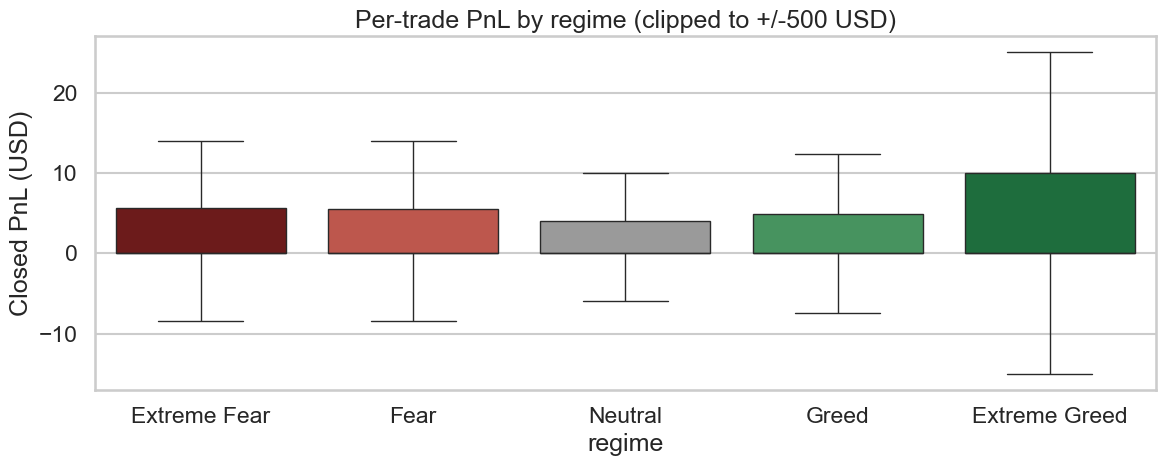

In [10]:
# Per-trade PnL distribution by regime (clipped for readability)
plot_df = df.dropna(subset=['regime']).copy()
plot_df['pnl_clip'] = plot_df['closed_pnl'].clip(-500, 500)
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=plot_df, x='regime', y='pnl_clip', order=REGIME_ORDER,
            hue='regime', palette=[PALETTE[r] for r in REGIME_ORDER],
            ax=ax, showfliers=False, legend=False)
ax.set_title('Per-trade PnL by regime (clipped to +/-500 USD)')
ax.set_ylabel('Closed PnL (USD)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'pnl_box_by_regime.png', dpi=140)
plt.show()


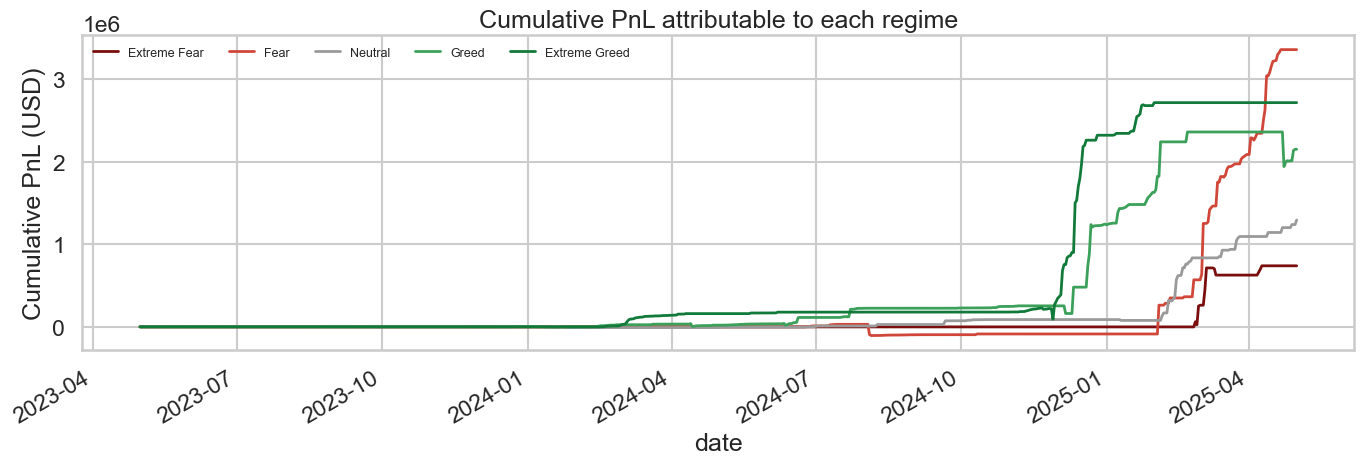

In [11]:
# Cumulative PnL split by regime
daily = df.dropna(subset=['regime']).groupby(['date', 'regime'], observed=True)['closed_pnl'].sum().unstack(fill_value=0)
daily = daily.reindex(columns=REGIME_ORDER, fill_value=0)
cumulative = daily.cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
for r in REGIME_ORDER:
    cumulative[r].plot(ax=ax, color=PALETTE[r], label=r, linewidth=2)
ax.set_title('Cumulative PnL attributable to each regime')
ax.set_ylabel('Cumulative PnL (USD)')
ax.legend(loc='upper left', ncol=5, fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cumulative_pnl_by_regime.png', dpi=140)
plt.show()


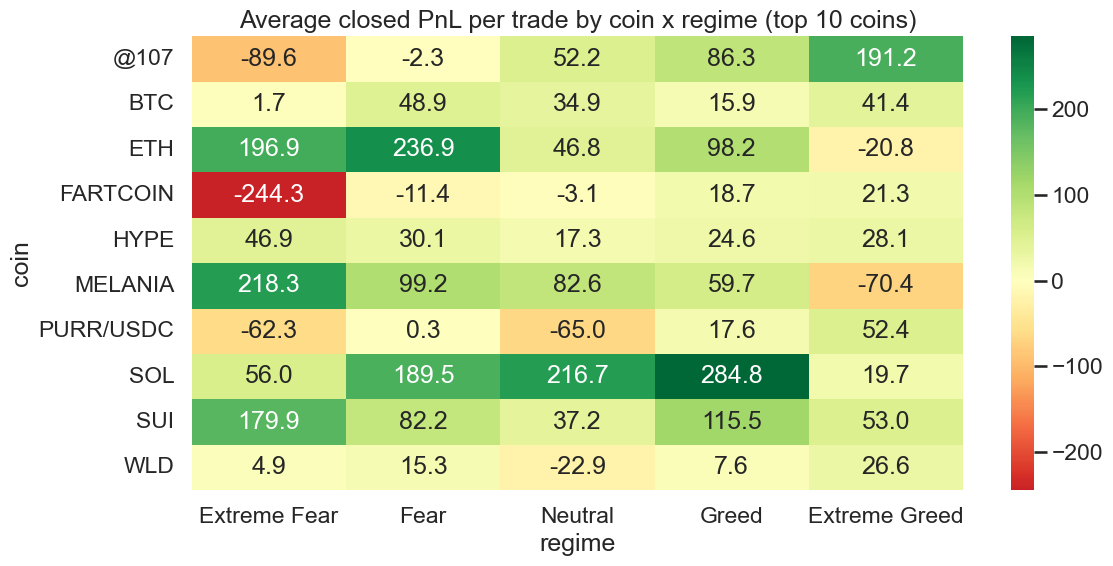

In [12]:
# Symbol x regime heatmap on top coins by trade count
top_coins = df['coin'].value_counts().head(10).index.tolist()
heat_src = df[df['coin'].isin(top_coins)].dropna(subset=['regime'])
heat = heat_src.groupby(['coin', 'regime'], observed=True)['closed_pnl'].mean().unstack('regime')
heat = heat.reindex(columns=REGIME_ORDER)
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Average closed PnL per trade by coin x regime (top 10 coins)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'coin_regime_heatmap.png', dpi=140)
plt.show()


## 6. Statistical tests

In [13]:
# Welch's t-test and Mann-Whitney on Fear vs Greed (binary collapse)
binary = df.dropna(subset=['regime']).copy()
fear = binary.loc[binary['regime_binary'] == 'Fear', 'closed_pnl']
greed = binary.loc[binary['regime_binary'] == 'Greed', 'closed_pnl']
t_stat, t_p = stats.ttest_ind(fear, greed, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(fear, greed, alternative='two-sided')
print(f'Fear n={len(fear)}, Greed n={len(greed)}')
print(f'Fear mean PnL: {fear.mean():.3f}, Greed mean PnL: {greed.mean():.3f}')
print(f"Welch's t-test: t={t_stat:.4f}, p={t_p:.4g}")
print(f'Mann-Whitney U:  U={u_stat:.0f}, p={u_p:.4g}')


Fear n=83237, Greed n=90295
Fear mean PnL: 49.212, Greed mean PnL: 53.882
Welch's t-test: t=-0.9875, p=0.3234
Mann-Whitney U:  U=3725766115, p=0.000954


In [14]:
# Spearman correlation between daily sentiment value and daily aggregate PnL / win rate
daily_pnl = df.dropna(subset=['regime']).groupby('date').agg(
    pnl=('closed_pnl', 'sum'),
    trades=('closed_pnl', 'size'),
    wins=('is_win', 'sum'),
    fg_value=('fg_value', 'first'),
)
daily_pnl['win_rate'] = daily_pnl['wins'] / daily_pnl['trades']

r_pnl, p_pnl = stats.spearmanr(daily_pnl['fg_value'], daily_pnl['pnl'])
r_wr, p_wr = stats.spearmanr(daily_pnl['fg_value'], daily_pnl['win_rate'])
print(f'Spearman(fg_value, daily_pnl):     rho={r_pnl:.4f}, p={p_pnl:.4g}')
print(f'Spearman(fg_value, daily_win_rate): rho={r_wr:.4f}, p={p_wr:.4g}')


Spearman(fg_value, daily_pnl):     rho=0.0398, p=0.3842
Spearman(fg_value, daily_win_rate): rho=0.1905, p=2.716e-05


In [15]:
# Chi-square on side (BUY vs SELL) across regimes
side_tbl = pd.crosstab(df['regime'], df['side'])
chi2, p_chi, dof, expected = stats.chi2_contingency(side_tbl)
print(side_tbl)
print()
print(f'Chi-square: chi2={chi2:.2f}, dof={dof}, p={p_chi:.4g}')
print()
print('Long-share by regime:')
print((side_tbl['BUY'] / side_tbl.sum(axis=1)).round(4))


side             BUY   SELL
regime                     
Extreme Fear   10935  10465
Fear           30270  31567
Neutral        18969  18717
Greed          24576  25727
Extreme Greed  17940  22052

Chi-square: chi2=327.24, dof=4, p=1.439e-69

Long-share by regime:
regime
Extreme Fear     0.5110
Fear             0.4895
Neutral          0.5033
Greed            0.4886
Extreme Greed    0.4486
dtype: float64


## 7. Trader ranking and contrarian detection

Ranking is restricted to accounts that traded at least 200 times overall and have closed trades in both Fear and Greed regimes, so the metrics are meaningful.

In [16]:
MIN_TRADES = 200

per_trader = df.dropna(subset=['regime']).groupby('account').size()
active = per_trader[per_trader >= MIN_TRADES].index
trader_df = df[df['account'].isin(active)].dropna(subset=['regime'])
print(f'Active traders (>= {MIN_TRADES} trades): {len(active)}')


Active traders (>= 200 trades): 32


In [17]:
def rank_within_regime(slice_df: pd.DataFrame, label: str) -> pd.DataFrame:
    rows = []
    for acc, sub in slice_df.groupby('account'):
        m = all_metrics(sub)
        m['account'] = acc
        rows.append(m)
    out = pd.DataFrame(rows)
    out = out[out['trades'] >= 20]
    print(f'  ranked {len(out)} of {len(rows)} traders with >= 20 trades in this slice')
    out = out.sort_values('pnl_total', ascending=False)
    out['rank'] = np.arange(1, len(out) + 1)
    out.insert(0, 'regime', label)
    cols = ['regime', 'rank', 'account', 'trades', 'pnl_total', 'pnl_mean',
            'win_rate', 'profit_factor', 'sharpe', 'max_drawdown', 'roi']
    return out[cols].reset_index(drop=True)

overall = rank_within_regime(trader_df, 'overall')
overall.to_csv(TBL_DIR / 'top_traders_overall.csv', index=False)
overall.head(10).round(4)


  ranked 32 of 32 traders with >= 20 trades in this slice


,regime,rank,account,trades,pnl_total,pnl_mean,win_rate,profit_factor,sharpe,max_drawdown,roi
0,overall,1,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2.143383e+06,145.4817,0.7910,36.0956,4.0069,-10532.4622,0.0379
1,overall,2,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.1278,0.7927,4.7087,8.4696,-327505.9001,0.0259
2,overall,3,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,9.401638e+05,44.3641,0.9912,27208.3698,8.5810,0.0000,0.0138
3,overall,4,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,8.404226e+05,68.6844,0.8955,5.9020,9.7624,-71121.8207,0.0020
4,overall,5,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,8.360806e+05,20.8063,0.7631,3.8625,4.7576,-82781.2712,0.0113
5,overall,6,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4356,6.777471e+05,155.5893,0.9485,52.8046,8.8086,-2427.8738,0.0171
6,overall,7,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1590,4.293556e+05,270.0349,0.7463,7.4467,5.3821,-58219.7523,0.0374
7,overall,8,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,4.165419e+05,336.7355,1.0000,inf,8.6849,0.0000,0.1404
8,overall,9,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,3.790954e+05,38.3196,0.9263,8.6044,10.4164,-22303.6036,0.0147
9,overall,10,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1424,3.605395e+05,253.1879,0.7742,9.2971,4.5274,-10753.5985,0.1217


In [18]:
rankings = {}
for regime in REGIME_ORDER:
    slice_df = trader_df[trader_df['regime'] == regime]
    if slice_df['account'].nunique() == 0:
        continue
    ranked = rank_within_regime(slice_df, regime)
    rankings[regime] = ranked
    safe = regime.lower().replace(' ', '_')
    ranked.to_csv(TBL_DIR / f'top_traders_{safe}.csv', index=False)
    print(f'{regime}: {len(ranked)} traders ranked')

# Side-by-side top 5 per regime
top5 = pd.concat([r.head(5)[['regime', 'rank', 'account', 'pnl_total', 'win_rate', 'sharpe']]
                  for r in rankings.values()], ignore_index=True)
top5.round(3)


  ranked 29 of 32 traders with >= 20 trades in this slice
Extreme Fear: 29 traders ranked


  ranked 32 of 32 traders with >= 20 trades in this slice
Fear: 32 traders ranked
  ranked 29 of 31 traders with >= 20 trades in this slice


Neutral: 29 traders ranked
  ranked 29 of 31 traders with >= 20 trades in this slice
Greed: 29 traders ranked


  ranked 26 of 30 traders with >= 20 trades in this slice


Extreme Greed: 26 traders ranked


,regime,rank,account,pnl_total,win_rate,sharpe
0,Extreme Fear,1,0xbaaaf6571ab7d571043ff1e313a9609a10637864,261917.978,1.000,9.140
1,Extreme Fear,2,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,198900.562,0.497,9.461
2,Extreme Fear,3,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,166696.399,0.981,10.148
3,Extreme Fear,4,0x083384f897ee0f19899168e3b1bec365f52a9012,124769.221,1.000,15.931
4,Extreme Fear,5,0x4f93fead39b70a1824f981a54d4e55b278e9f760,74346.547,1.000,17.731
5,Fear,1,0x083384f897ee0f19899168e3b1bec365f52a9012,1113373.548,0.891,21.368
6,Fear,2,0xbaaaf6571ab7d571043ff1e313a9609a10637864,620872.376,0.986,8.922
7,Fear,3,0x513b8629fe877bb581bf244e326a047b249c4ff1,367166.217,0.860,14.165
8,Fear,4,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,296781.723,0.953,8.167
9,Fear,5,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,236797.728,0.841,5.073


In [19]:
# Contrarian detection: traders whose Fear performance is meaningfully better than their Greed performance, or vice versa.
fear_rank = rank_within_regime(trader_df[trader_df['regime_binary'] == 'Fear'], 'Fear')
greed_rank = rank_within_regime(trader_df[trader_df['regime_binary'] == 'Greed'], 'Greed')

f = fear_rank[['account', 'trades', 'pnl_mean', 'win_rate', 'sharpe']].add_suffix('_fear')
g = greed_rank[['account', 'trades', 'pnl_mean', 'win_rate', 'sharpe']].add_suffix('_greed')
f = f.rename(columns={'account_fear': 'account'})
g = g.rename(columns={'account_greed': 'account'})

contra = f.merge(g, on='account', how='inner')
contra = contra[(contra['trades_fear'] >= 50) & (contra['trades_greed'] >= 50)]
contra['fear_minus_greed_winrate'] = contra['win_rate_fear'] - contra['win_rate_greed']
contra['fear_minus_greed_sharpe'] = contra['sharpe_fear'] - contra['sharpe_greed']

fear_specialists = contra.sort_values('fear_minus_greed_winrate', ascending=False).head(10)
greed_specialists = contra.sort_values('fear_minus_greed_winrate', ascending=True).head(10)

contra.sort_values('fear_minus_greed_winrate', ascending=False).to_csv(TBL_DIR / 'contrarian_traders.csv', index=False)

print('Fear specialists (best Fear win rate edge):')
print(fear_specialists[['account', 'win_rate_fear', 'win_rate_greed', 'fear_minus_greed_winrate', 'sharpe_fear', 'sharpe_greed']].round(3).to_string(index=False))
print()
print('Greed specialists (best Greed win rate edge):')
print(greed_specialists[['account', 'win_rate_fear', 'win_rate_greed', 'fear_minus_greed_winrate', 'sharpe_fear', 'sharpe_greed']].round(3).to_string(index=False))


  ranked 32 of 32 traders with >= 20 trades in this slice
  ranked 29 of 31 traders with >= 20 trades in this slice
Fear specialists (best Fear win rate edge):
                                   account  win_rate_fear  win_rate_greed  fear_minus_greed_winrate  sharpe_fear  sharpe_greed
0x271b280974205ca63b716753467d5a371de622ab          0.955           0.439                     0.516       31.724        -7.567
0x083384f897ee0f19899168e3b1bec365f52a9012          0.894           0.388                     0.506       18.470         2.807
0x8477e447846c758f5a675856001ea72298fd9cb5          0.822           0.554                     0.268       11.502         1.424
0x8170715b3b381dffb7062c0298972d4727a0a63b          0.849           0.686                     0.163       10.609        -4.040
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          0.875           0.729                     0.146        4.685         4.185
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3          0.788           0.707     

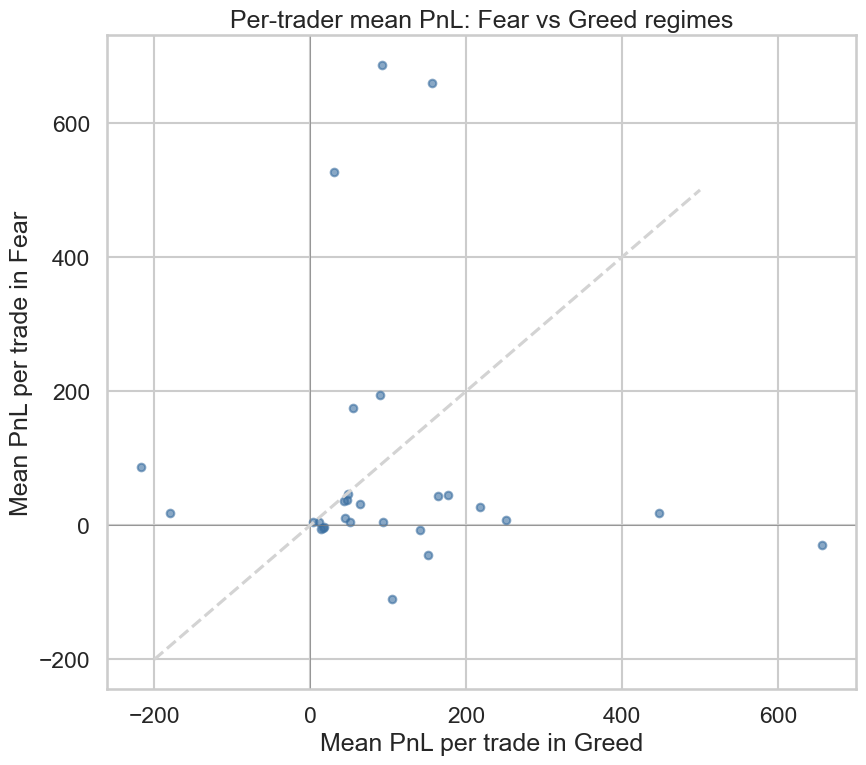

In [20]:
# Scatter of Fear vs Greed mean PnL per trader, contrarian quadrants visible
fig, ax = plt.subplots(figsize=(9, 8))
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.scatter(contra['pnl_mean_greed'], contra['pnl_mean_fear'], s=30, alpha=0.6, color='#3a6ea0')
ax.plot([-200, 500], [-200, 500], color='lightgray', linestyle='--')
ax.set_xlabel('Mean PnL per trade in Greed')
ax.set_ylabel('Mean PnL per trade in Fear')
ax.set_title('Per-trader mean PnL: Fear vs Greed regimes')
plt.tight_layout()
plt.savefig(FIG_DIR / 'contrarian_scatter.png', dpi=140)
plt.show()


## 8. Summary numbers for the report

Most important numbers reprinted in a compact block so the report can cite them.

In [21]:
summary_lines = []
for r in REGIME_ORDER:
    row = regime_table[regime_table['regime'] == r].iloc[0]
    summary_lines.append(
        f"{r:14s} trades={int(row['trades']):>7d}  "
        f"pnl_mean=${row['pnl_mean']:>7.2f}  "
        f"win_rate={row['win_rate']:.3f}  "
        f"pf={row['profit_factor']:.2f}  "
        f"sharpe={row['sharpe']:.2f}  "
        f"roi={row['roi']:.4f}  "
        f"mdd={row['max_drawdown']:>+12,.0f}"
    )
print('\n'.join(summary_lines))
print()
print(f"Fear vs Greed t-test p-value: {t_p:.4g}")
print(f"Spearman(fg_value, daily_pnl) rho: {r_pnl:.4f} (p={p_pnl:.4g})")
print(f"Long share Extreme Fear -> Extreme Greed:")
print((side_tbl['BUY'] / side_tbl.sum(axis=1)).reindex(REGIME_ORDER).round(4).to_string())


Extreme Fear   trades=  21400  pnl_mean=$  34.54  win_rate=0.762  pf=2.16  sharpe=9.96  roi=0.0065  mdd=     -86,891
Fear           trades=  61837  pnl_mean=$  54.29  win_rate=0.873  pf=6.66  sharpe=7.30  roi=0.0069  mdd=    -135,686
Neutral        trades=  37686  pnl_mean=$  34.31  win_rate=0.824  pf=4.32  sharpe=9.70  roi=0.0072  mdd=     -10,117
Greed          trades=  50303  pnl_mean=$  42.74  win_rate=0.769  pf=3.03  sharpe=3.41  roi=0.0075  mdd=    -419,020
Extreme Greed  trades=  39992  pnl_mean=$  67.89  win_rate=0.892  pf=11.02  sharpe=6.25  roi=0.0218  mdd=    -137,370

Fear vs Greed t-test p-value: 0.3234
Spearman(fg_value, daily_pnl) rho: 0.0398 (p=0.3842)
Long share Extreme Fear -> Extreme Greed:
regime
Extreme Fear     0.5110
Fear             0.4895
Neutral          0.5033
Greed            0.4886
Extreme Greed    0.4486
